# Exercises for Thursday morning

In this exercise you will

- perform initial state preparation using the Variational Quantum Eigensolver
- implement read-out error mitigation on both simulators and real hardware

## Intro on state preparation

As a first step we define a circuit block applying an $XY$ rotation gate defined as

$$rXY(\theta,a,b) = \exp\left(-i\theta X_aY_b\right)$$

Applied to the state $\rvert 00\rangle$ this will give

$$rXY(\theta,0,1)\rvert 00\rangle =\exp\left(-i\theta X_aY_b\right)\rvert 00\rangle=\left[\cos(\theta)-i\sin(\theta)XY\right]\rvert 00\rangle=\cos(\theta)\rvert 00\rangle+\sin(\theta)\rvert 11\rangle $$

For an Ising model with $2$ sites this allows to find a good approximation to the ground-state. In order to keep the ansatz simple we will use a similar transformation also for $N$ sites: this will allow for a simple parameter optimization at the cost of providing a worse approximation to the Hamiltonian ground-state. Our variational ansatz will then be

$$\rvert \Psi_N(\theta)\rangle = \prod_{j=0}^{N-2}rXY(\theta,j,j+1) \rvert00\cdots0\rangle$$

### Example for N=2

Take $N=2$ sites and the Hamiltonian

$$H=-Z_0-Z_1+X_0X_1$$

then we have the following results

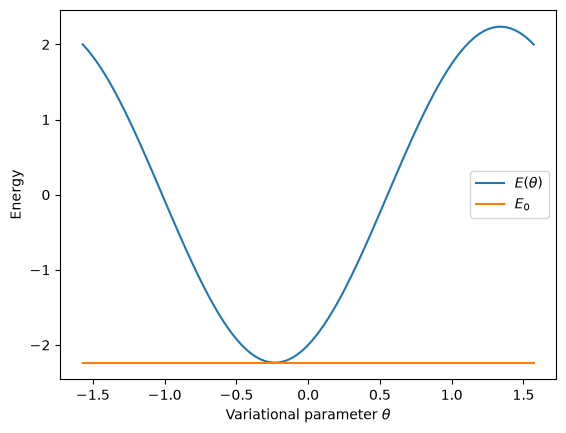

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# let's code the ideal circuit in numpy first
## we start defining all the Pauli observables
I = np.eye(2)
X = np.array([[0,1],[1,0]],dtype=complex)
Y = np.array([[0,-1.j],[1.j,0]],dtype=complex)
Z = np.array([[1,0],[0,-1]],dtype=complex)
# and now all possible two qubit observables
## NOTE: qiskit uses an ordering that goes left to right, we will do the same here
X_1 = np.kron(X,I); Y_1 = np.kron(Y,I); Z_1 = np.kron(Z,I)
X_0 = np.kron(I,X); Y_0 = np.kron(I,Y); Z_0 = np.kron(I,Z)
X_0X_1 = np.kron(X,X); Y_0X_1 = np.kron(X,Y); Z_0X_1 = np.kron(X,Z)
X_0Y_1 = np.kron(Y,X); Y_0Y_1 = np.kron(Y,Y); Z_0Y_1 = np.kron(Y,Z)
X_0Z_1 = np.kron(Z,X); Y_0Z_1 = np.kron(Z,Y); Z_0Z_1 = np.kron(Z,Z)

# Hamiltonian
H=-Z_0-Z_1+X_0X_1
# these are the computational states
zero_state=np.array([1,0])
one_state=np.array([0,1])

## ground state energy
E_ground = np.sort(np.real(np.linalg.eigvals(H)))[0]

## Compute energy expectation value for our ansatz
theta_values2=np.linspace(-np.pi/2,np.pi/2,100)
energies2 = []
for angle in theta_values2:
    state_now = np.cos(angle)*np.kron(zero_state,zero_state)+np.sin(angle)*np.kron(one_state,one_state)
    e_now = np.real(np.vdot(state_now,H@state_now))
    energies2.append(e_now)

## Compare with exact result
plt.plot(theta_values2,energies2,label="$E(\\theta)$")
plt.plot(theta_values2,np.ones(len(theta_values2))*E_ground,label="$E_0$")
plt.ylabel("Energy")
plt.xlabel("Variational parameter $\\theta$")
plt.legend()
plt.show()

# EXERCISE

Implement the variational protocol as a quantum circuit for $N=2$ and $N=3$. You should

- verify your implementation is correct comparing the exact result with a state vector simulation
- perform the calculation collecting a finite number of shots and estimating the resulting statistical error
- apply the read out error mitigation protocol seen in class (check also the `ErrorMitigation-ReadOut` notebook) to a noise simulator
- run the full VQE protocol, with read out mitigation, on hardware

-----------------------------------------------------------------------------------------------------------------------

## Helpful things

You should be able to just go and do the exercise on your own but if you want them here are a few helpful tips and examples

### 1.Fake backends

When you will run circuit simulations, especially when adding a noise model, it is helpful to define ad-hoc backends for the job like the following

In [2]:
from qiskit.providers.fake_provider import GenericBackendV2
# Generate a 2-qubit simulated backend
my_coupling_map2 = [(0, 1)] 
fake_2qubits = GenericBackendV2(
    num_qubits=2,
    coupling_map=my_coupling_map2,
    basis_gates=["id", "rz", "sx", "x", "cz"],
    seed=42 # set a fixed seed for PRNG
)

# Generate a 3-qubit simulated backend with linear connectivity
my_coupling_map3_lin = [(0, 1), (1,2)] 
fake_3qubits = GenericBackendV2(
    num_qubits=3,
    coupling_map=my_coupling_map3_lin,
    basis_gates=["id", "rz", "sx", "x", "cz"],
    seed=42 # set a fixed seed for PRNG
)

# Generate a 3-qubit simulated backend with connectivity similar to a piece of Lagrange
my_coupling_map3_lag = [(0, 2), (1,2)] 
fake_3qubits = GenericBackendV2(
    num_qubits=3,
    coupling_map=my_coupling_map3_lag,
    basis_gates=["id", "rz", "sx", "x", "cz"],
    seed=42 # set a fixed seed for PRNG
)

remember to always transpile your circuits before execution! And before harware runs check that the transpilation does what you expected it to do.

### 2. Noise models
When running a simulation with a noise model you can use

In [ ]:
from qiskit_aer.noise import NoiseModel

# for the 2 qubit backend
noise_model2 = NoiseModel.from_backend(fake_2qubits)
sim_noisy2 = AerSimulator(noise_model=noise_model2,target=fake_2qubits)
## to run simply use the following (seed is set just to allow result to be reproducible)
sim_noisy2.run(list_of_circuits, # a list of transipled circuits
               shots=how_many_shots_I_want, # an integer value
               seed_simulator=42)
# for the 3 qubit backend
noise_model3 = NoiseModel.from_backend(fake_3qubits)
sim_noisy3 = AerSimulator(noise_model=noise_model3,target=fake_3qubits)

### 3. Energy expectation values

In order to compute the energy from a collection of counts you could use the following routines

In [3]:
def exp_err_from_counts(input_counts, bits_for_observable):
    average_obs = 0.0
    err_obs = 0.0
    tot_counts = 0
    for cc in input_counts:
        ## convert the measured bit-string into a list of numerical values
        int_bit_string = [int(bb) for bb in cc]
        ## compute the sum of bits (note the ordering convention)
        num_qubits = len(int_bit_string)
        exp_sum = sum([int_bit_string[num_qubits-1-bit] for bit in bits_for_observable])
        ## convert this into the corresponding value
        value = (-1)**exp_sum
        ## and accumulate the result by multiplying the number of counts
        average_obs += input_counts[cc]*value
        ## together with the cumulative number of counts
        tot_counts += input_counts[cc]
    ## we finish by dividing by the total number of counts
    average_obs /= tot_counts
    ## estimate error
    err_obs = np.sqrt((1.-average_obs**2)/(tot_counts-1))
    return average_obs, err_obs

def get_energy_and_errors3(counts,J=1.0):
    num_thetas = len(counts)//2

    E_of_theta = np.zeros(num_thetas)
    err_E_of_theta = np.zeros(num_thetas)
    for tidx in range(num_thetas):
        ## Z_0
        z0,ez0 = exp_err_from_counts(counts[2*tidx],[0])
        ## Z_1
        z1,ez1 = exp_err_from_counts(counts[2*tidx],[1])
        ## Z_2
        z2,ez2 = exp_err_from_counts(counts[2*tidx],[2])
        ## X_0X_1
        x0x1,ex0x1 = exp_err_from_counts(counts[2*tidx+1],[0,1])
        ## X_1X_2
        x1x2,ex1x2 = exp_err_from_counts(counts[2*tidx+1],[1,2])
        ### energy
        E_of_theta[tidx] = -(z0+z1+z2) + J*(x0x1+x1x2)
        ### adding errors in quadrature (can you do better?)
        err_E_of_theta[tidx] = np.sqrt(ez0**2+ez1**2+ez2**2+(J**2)*(ex0x1**2+ex1x2**2))

    return E_of_theta, err_E_of_theta

The function `get_energy_and_errors` assumes the following form for a 3 site Hamiltonian

$$H_3 = -Z_0-Z_1-Z_2 + J \left(X_0X_1+X_1X_2\right)$$

it should be easy to modify if you want something else. The input counts to this function are twice the number of $\theta$ angles you want and are ordered such that the even ones contain measurement of $Z$ expectation values and the odd one of $X$ expectation values instead.

### 4. Read out error mitigation

Some of the functions introduced in the `ErrorMitigation-ReadOut` notebook have been implemented, for your ease of use, in the `error_mit.py` script.

### 5. Running on hardware

When you try to run on Lagrange remember that you can use the following syntax

In [ ]:
#
# [... load your credentials ...]
#
### IQM Lagrange
# from iqm.qiskit_iqm import IQMProvider
# !lagrangeclient
###
#
# import os
# os.environ["IQM_TOKENS_FILE"] = "./tokens.json"
#
# iqm_url = "https://spark.quantum.linksfoundation.com/"
# quantum_computer = "default"
#
# lagrange_provider = IQMProvider(iqm_url,quantum_computer=quantum_computer)
#
## get the actual backend
lagrange_backend = lagrange_provider.get_backend()
#
# [... prepare all of your circuits ...]
#
job_backend = lagrange_backend.run(transpiled_circuit_list,shots=how_many_shots_you_want)
#
# wait for job to be DONE and then get the counts using
#
lag_counts = job_backend.result().get_counts()

For IBM instead running directly from the backend is deprecated and you should use a Sampler as follows

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
#
# [... load your credentials ...]
#
## this one will automatically load them if you saved them locally
ibmq_service = QiskitRuntimeService()
## get the actual backend (fez in this case)
fez_backend = ibmq_service.backend('ibm_fez')
#
# [... prepare all of your circuits ...]
#
## now we prepare an instance of Sampler
from qiskit_ibm_runtime import SamplerV2

ibm_sampler = SamplerV2(fez_backend)
ibm_sampler.options.default_shots = how_many_shots_you_want

job_fez = ibm_sampler.run(transpiled_circuit_list)
#
# wait for job to be DONE and then get the counts using
#
fez_counts = []
for res in job_fez.result():
    fez_counts.append(res.data.meas.get_counts())

-----------------------------------------------------------------------------------------------------------------------
# Completed $N=2$ case

If you are struggling in the implementation maybe the following example for $N=2$ could help you

### 1. Circuit implementation

In [4]:
from qiskit import QuantumCircuit

## here we use the rxx gate implemented in qiskit
def add_rXY(circ,angle,a,b):
    circ.sdg(b)
    ## NOTE factor of 2 to comply with qiskit conventions
    circ.rxx(2*angle,a,b)
    circ.s(b)
    
## make the circuits first
circuits_vqe = []
for angle in theta_values2:
    circ_now = QuantumCircuit(2)
    add_rXY(circ_now,angle,0,1)
    circuits_vqe.append(circ_now)

### 2. Test on state vector simulator

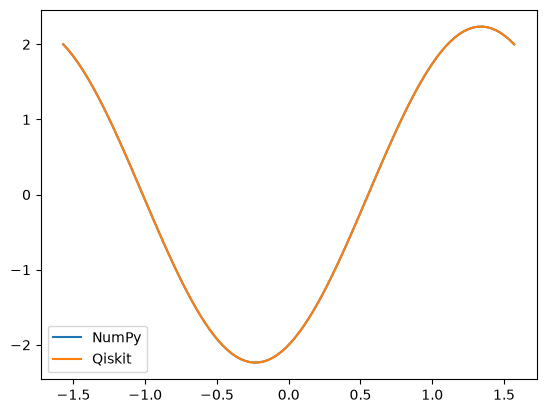

In [5]:
from qiskit import transpile
from qiskit_aer import AerSimulator

# transpile for this target
transpiled_circuits_sv = []
for circ in circuits_vqe:
    transpiled = transpile(circ, 
                                backend=fake_2qubits,
                                optimization_level=0,
                                initial_layout=[0,1]
                    )
    transpiled_circuits_sv.append(transpiled)

# run circuits and extract expectation values
sim_statevector = AerSimulator(method='statevector')
energies_sv = []

for idx,circ in enumerate(transpiled_circuits_sv):
    circ.save_statevector()
    job_sv = sim_statevector.run(circ)
    result_sv = job_sv.result()
    outputstate_sv = result_sv.get_statevector(circ, decimals=8)
    npstate = np.array(outputstate_sv.data.tolist())
    e_now = np.real(np.vdot(npstate,H@npstate))
    energies_sv.append(e_now)

## visually check with a plot
plt.plot(theta_values2,energies2,label="NumPy")
plt.plot(theta_values2,energies_sv,label="Qiskit")
plt.legend()
plt.show()

### 3. Test with finite number of shots

In [6]:
## QASM version
## transpile for this target
transpiled_circuits_qasm = []
## cycle on bare circuits
for circ in circuits_vqe:
    transpiled = transpile(circ, 
                                backend=fake_2qubits,
                                optimization_level=2,
                                initial_layout=[0,1]
                    )
    ## add z measurements
    ### the additional arguments creates a new circuit instead of modifying the current one
    t_circ_mz = transpiled.measure_active(inplace=False)
    transpiled_circuits_qasm.append(t_circ_mz)
    ## add x measurements
    transpiled.h([0,1])
    transpiled.measure_active()
    transpiled_circuits_qasm.append(transpiled)

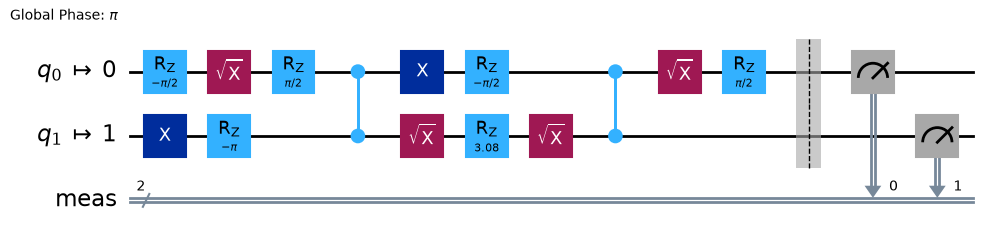

In [7]:
transpiled_circuits_qasm[2].draw('mpl')

In [8]:
## here we fix the random seed to a fixed random number for reproducibility
sample_job = sim_statevector.run(transpiled_circuits_qasm,shots=1024,seed_simulator=21)

In [9]:
qasm_counts = sample_job.result().get_counts()

In [10]:
def get_energy_and_errors2(counts,J=1.0):
    num_thetas = len(counts)//2

    E_of_theta = np.zeros(num_thetas)
    err_E_of_theta = np.zeros(num_thetas)
    for tidx in range(num_thetas):
        ## Z_0
        z0,ez0 = exp_err_from_counts(counts[2*tidx],[0])
        ## Z_1
        z1,ez1 = exp_err_from_counts(counts[2*tidx],[1])
        ## X_0X_1
        x0x1,ex0x1 = exp_err_from_counts(counts[2*tidx+1],[0,1])
        ### energy
        E_of_theta[tidx] = -(z0+z1) + J*x0x1
        err_E_of_theta[tidx] = np.sqrt(ez0**2+ez1**2+(J**2)*(ex0x1**2))

    return E_of_theta, err_E_of_theta

In [11]:
E_of_theta, err_E_of_theta = get_energy_and_errors2(qasm_counts)

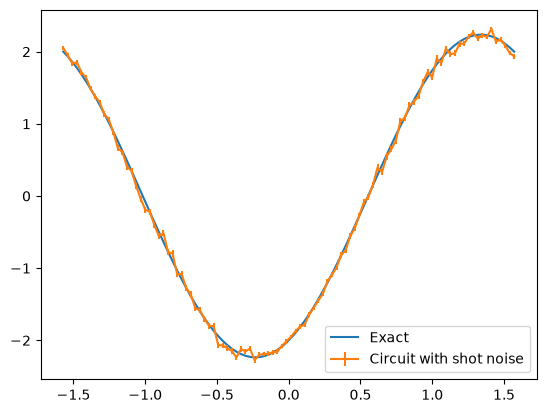

In [12]:
plt.plot(theta_values2,energies2, label="Exact")
plt.errorbar(theta_values2,E_of_theta,yerr=err_E_of_theta, label="Circuit with shot noise")
plt.legend()
plt.show()

### 4. Final run with noise and RO mitigation

In [13]:
from qiskit_aer.noise import NoiseModel

noise_model = NoiseModel.from_backend(fake_2qubits)
sim_noisy = AerSimulator(noise_model=noise_model,target=fake_2qubits)

In [14]:
## circuits for read-out calibration
cal_circuits_simple = []
## first one for the 00 string
cal_circ_00 = QuantumCircuit(2)
cal_circ_00.measure_all()
cal_circuits_simple.append(cal_circ_00)
## last one for the 11 string
cal_circ_11 = QuantumCircuit(2)
cal_circ_11.x(0)
cal_circ_11.x(1)
cal_circ_11.measure_all()
cal_circuits_simple.append(cal_circ_11)

In [15]:
transpiled_circuits = []
for circ in cal_circuits_simple:
    transpiled = transpile(circ, 
                                backend=fake_2qubits,
                                optimization_level=0,
                                initial_layout=[0,1]
                    )
    transpiled_circuits.append(transpiled)
for circ in circuits_vqe:
    ## add z measurements
    ### the additional arguments creates a new circuit instead of modifying the current one
    circ_now = circ.measure_active(inplace=False)
    transpiled = transpile(circ_now, 
                                backend=fake_2qubits,
                                optimization_level=2,
                                initial_layout=[0,1]
                    )
    transpiled_circuits.append(transpiled)
    ## add x measurements
    circ_now = circ.copy()
    circ_now.h([0,1])
    circ_now.measure_active()
    transpiled = transpile(circ_now, 
                                backend=fake_2qubits,
                                optimization_level=2,
                                initial_layout=[0,1]
                    )    
    transpiled_circuits.append(transpiled)

In [16]:
noise_job = sim_noisy.run(transpiled_circuits,shots=1024,seed_simulator=21)
counts_noise = noise_job.result().get_counts()

In [17]:
# first we check what we've got without mitigation
E_of_theta_noise, err_E_of_theta_noise = get_energy_and_errors2(counts_noise[2:])

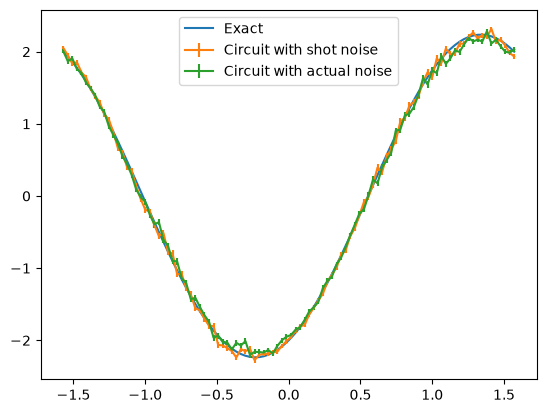

In [18]:
plt.plot(theta_values2,energies2, label="Exact")
plt.errorbar(theta_values2,E_of_theta,yerr=err_E_of_theta, label="Circuit with shot noise")
plt.errorbar(theta_values2,E_of_theta_noise,yerr=err_E_of_theta_noise, label="Circuit with actual noise")
plt.legend()
plt.show()

The circuit is so simple, and the noise model so optimistic, that there is little to mitigate here. But we'll do it anyway

In [19]:
from error_mit import get_single_qubit_ro_probs, get_mit_counts, fix_negative
## extract calibration matrices
cal_matrices = get_single_qubit_ro_probs(counts_noise[0:2])
print(cal_matrices)

_Found 2 qubits in first calibration circuit counts
[array([[1.        , 0.00292969],
       [0.        , 0.99707031]]), array([[0.99707031, 0.00683594],
       [0.00292969, 0.99316406]])]


In [20]:
## obtain corrected counts
num_qubits = 2
mit_counts = []
for rc in counts_noise:
    mc = get_mit_counts(rc,num_qubits,cal_matrices)
    mit_counts.append(mc)

In [21]:
E_of_theta_mit, err_E_of_theta_mit = get_energy_and_errors2(mit_counts[2:])

/tmp/ipykernel_394364/818070444.py:20: RuntimeWarning: invalid value encountered in sqrt
  err_obs = np.sqrt((1.-average_obs**2)/(tot_counts-1))


In [24]:
## fix the negative counts by hand and try again
fn_mit_counts = [fix_negative(mc) for mc in mit_counts]
E_of_theta_mit, err_E_of_theta_mit = get_energy_and_errors2(fn_mit_counts[2:])

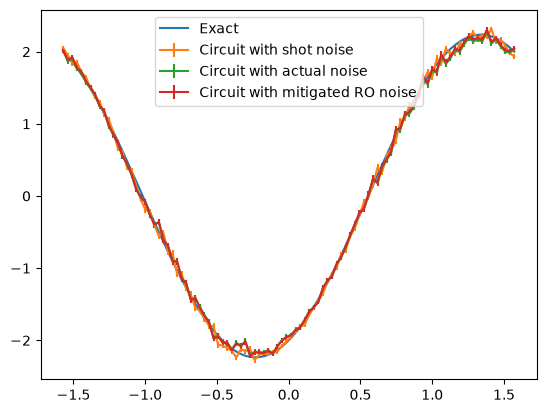

In [25]:
plt.plot(theta_values2,energies2, label="Exact")
plt.errorbar(theta_values2,E_of_theta,yerr=err_E_of_theta, label="Circuit with shot noise")
plt.errorbar(theta_values2,E_of_theta_noise,yerr=err_E_of_theta_noise, label="Circuit with actual noise")
plt.errorbar(theta_values2,E_of_theta_mit,yerr=err_E_of_theta_mit, label="Circuit with mitigated RO noise")
plt.legend()
plt.show()